In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!rm -rf /content/drive


In [ ]:
!ls -la /content


total 16
drwxr-xr-x 1 root root 4096 Feb  1 09:24 .
drwxr-xr-x 1 root root 4096 Feb  1 09:20 ..
drwxr-xr-x 4 root root 4096 Jan 16 14:24 .config
drwxr-xr-x 1 root root 4096 Jan 16 14:24 sample_data


MODEL SENTIMEN

Jumlah data: 26813

Distribusi label:
Sentimen
negatif    18296
positif     8517
Name: count, dtype: int64

Persentase label (%):
Sentimen
negatif    68.24
positif    31.76
Name: proportion, dtype: float64

Proses Stratified 10-Fold Cross Validation

Fold 1
Accuracy: 0.8706 | Macro F1: 0.8513 | Weighted F1: 0.8708

Fold 2
Accuracy: 0.8669 | Macro F1: 0.8485 | Weighted F1: 0.8677

Fold 3
Accuracy: 0.8680 | Macro F1: 0.8491 | Weighted F1: 0.8686

Fold 4
Accuracy: 0.8702 | Macro F1: 0.8514 | Weighted F1: 0.8707

Fold 5
Accuracy: 0.8635 | Macro F1: 0.8441 | Weighted F1: 0.8642

Fold 6
Accuracy: 0.8612 | Macro F1: 0.8430 | Weighted F1: 0.8625

Fold 7
Accuracy: 0.8724 | Macro F1: 0.8533 | Weighted F1: 0.8726

Fold 8
Accuracy: 0.8635 | Macro F1: 0.8441 | Weighted F1: 0.8641

Fold 9
Accuracy: 0.8579 | Macro F1: 0.8380 | Weighted F1: 0.8587

Fold 10
Accuracy: 0.8542 | Macro F1: 0.8348 | Weighted F1: 0.8554

Rata-rata performa 10-Fold:
Fold           5.500000
Accuracy       0.864841
Macro F1    

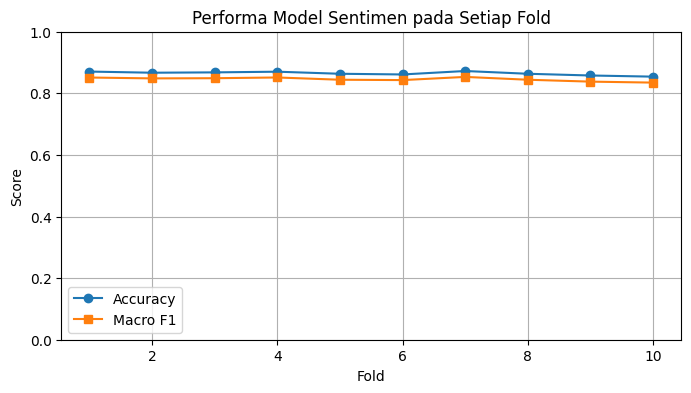


Pelatihan model final dengan pembagian data 80:20

Perbandingan performa Train dan Test
Train Accuracy : 0.8958
Test Accuracy  : 0.8594
Train Macro F1 : 0.8820
Test Macro F1  : 0.8401

Classification Report (Data Test):

              precision    recall  f1-score   support

     negatif       0.91      0.88      0.90      3659
     positif       0.76      0.81      0.78      1704

    accuracy                           0.86      5363
   macro avg       0.84      0.84      0.84      5363
weighted avg       0.86      0.86      0.86      5363



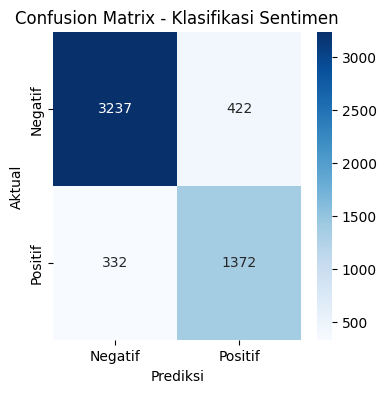

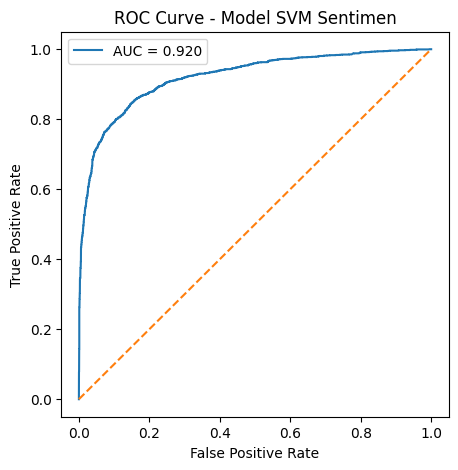


Ringkasan performa akhir:
Accuracy  : 0.8594
Macro F1  : 0.8401
AUC Score : 0.9204

Analisis Overfitting Model Sentimen
Accuracy Gap : 0.0364
Macro F1 Gap : 0.0420
Model cukup stabil dan tidak menunjukkan overfitting signifikan

Model TF-IDF dan SVM berhasil disimpan.


In [ ]:
# =========================================
# IMPORT LIBRARY
# =========================================
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# =========================================
# PATH
# =========================================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
MODEL_DIR = "/content/drive/MyDrive/skripsi/model"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DATA_DIR, "dataset_sentimen.csv"))

# =========================================
# PERSIAPAN DATA
# =========================================
df = df.dropna(subset=["clean_text_stem", "Sentimen"])
df["text_used"] = df["clean_text_stem"].astype(str).str.strip()
df = df[df["text_used"] != ""]

X = df["text_used"]
y = df["Sentimen"].str.lower()

print("Jumlah data:", len(df))
print("\nDistribusi label:")
print(y.value_counts())
print("\nPersentase label (%):")
print((y.value_counts(normalize=True) * 100).round(2))

# =====================================================
# STRATIFIED 10-FOLD CROSS VALIDATION
# =====================================================
print("\nProses Stratified 10-Fold Cross Validation")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nFold {fold}")

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    tfidf = TfidfVectorizer(
        ngram_range=(1,2),
        max_features=15000,
        min_df=4,
        max_df=0.85,
        sublinear_tf=True,
        stop_words=None
    )

    X_train_vec = tfidf.fit_transform(X_train)
    X_test_vec  = tfidf.transform(X_test)

    model = LinearSVC(C=0.3, max_iter=7000, class_weight="balanced")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    fold_results.append([fold, acc, f1_macro, f1_weighted])

    print(f"Accuracy: {acc:.4f} | Macro F1: {f1_macro:.4f} | Weighted F1: {f1_weighted:.4f}")

df_folds = pd.DataFrame(fold_results, columns=["Fold","Accuracy","Macro F1","Weighted F1"])

print("\nRata-rata performa 10-Fold:")
print(df_folds.mean(numeric_only=True))

plt.figure(figsize=(8,4))
plt.plot(df_folds["Fold"], df_folds["Accuracy"], marker='o', label="Accuracy")
plt.plot(df_folds["Fold"], df_folds["Macro F1"], marker='s', label="Macro F1")
plt.title("Performa Model Sentimen pada Setiap Fold")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()

# =====================================================
# TRAIN MODEL FINAL (80:20 SPLIT)
# =====================================================
print("\nPelatihan model final dengan pembagian data 80:20")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

tfidf_final = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=12000,
    min_df=8,
    max_df=0.9,
    sublinear_tf=True,
    stop_words=None
)

X_train_vec = tfidf_final.fit_transform(X_train)
X_test_vec  = tfidf_final.transform(X_test)

svm_final = LinearSVC(C=0.1, max_iter=5000, class_weight=class_weights)
svm_final.fit(X_train_vec, y_train)

# =========================
# EVALUASI MODEL
# =========================
y_train_pred = svm_final.predict(X_train_vec)
y_test_pred  = svm_final.predict(X_test_vec)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)

train_f1_macro = f1_score(y_train, y_train_pred, average="macro")
test_f1_macro  = f1_score(y_test, y_test_pred, average="macro")

print("\nPerbandingan performa Train dan Test")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Train Macro F1 : {train_f1_macro:.4f}")
print(f"Test Macro F1  : {test_f1_macro:.4f}")

print("\nClassification Report (Data Test):\n")
print(classification_report(y_test, y_test_pred))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_test_pred, labels=["negatif","positif"])
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negatif","Positif"],
            yticklabels=["Negatif","Positif"])
plt.title("Confusion Matrix - Klasifikasi Sentimen")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# =========================
# ROC CURVE
# =========================
y_test_bin = label_binarize(y_test, classes=["negatif", "positif"]).ravel()
y_scores = svm_final.decision_function(X_test_vec)

fpr, tpr, _ = roc_curve(y_test_bin, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model SVM Sentimen")
plt.legend()
plt.show()

print("\nRingkasan performa akhir:")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Macro F1  : {test_f1_macro:.4f}")
print(f"AUC Score : {roc_auc:.4f}")

# =========================================
# ANALISIS OVERFITTING
# =========================================
acc_gap = train_acc - test_acc
f1_gap  = train_f1_macro - test_f1_macro

print("\nAnalisis Overfitting Model Sentimen")
print(f"Accuracy Gap : {acc_gap:.4f}")
print(f"Macro F1 Gap : {f1_gap:.4f}")

if acc_gap > 0.07 or f1_gap > 0.07:
    print("Model menunjukkan indikasi overfitting ringan")
else:
    print("Model cukup stabil dan tidak menunjukkan overfitting signifikan")

# =========================================
# SIMPAN MODEL
# =========================================
joblib.dump(tfidf_final, os.path.join(MODEL_DIR, "tfidf_sentimen.pkl"))
joblib.dump(svm_final, os.path.join(MODEL_DIR, "svm_sentimen.pkl"))

print("\nModel TF-IDF dan SVM berhasil disimpan.")


MODEL ASPEK

Jumlah data: 33846

Distribusi label aspek:
Aspek
Aplikasi & Fitur      8161
Harga & Pembayaran    7186
Konten                7110
Umum                  4952
Akun & Akses          4810
Kualitas Streaming    1627
Name: count, dtype: int64

Stratified 10-Fold Cross Validation
Fold 1 - Accuracy: 0.9530, Macro F1: 0.9495
Fold 2 - Accuracy: 0.9536, Macro F1: 0.9493
Fold 3 - Accuracy: 0.9462, Macro F1: 0.9425
Fold 4 - Accuracy: 0.9545, Macro F1: 0.9511
Fold 5 - Accuracy: 0.9542, Macro F1: 0.9509
Fold 6 - Accuracy: 0.9498, Macro F1: 0.9476
Fold 7 - Accuracy: 0.9512, Macro F1: 0.9501
Fold 8 - Accuracy: 0.9507, Macro F1: 0.9495
Fold 9 - Accuracy: 0.9539, Macro F1: 0.9494
Fold 10 - Accuracy: 0.9453, Macro F1: 0.9426

Rata-rata performa 10-Fold:
Fold        5.500000
Accuracy    0.951250
Macro F1    0.948257
dtype: float64


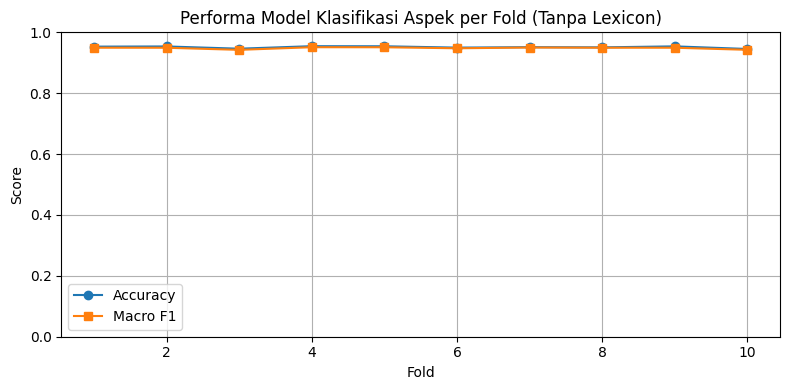


Pelatihan model final

Perbandingan performa Train dan Test
Train Accuracy : 0.9943
Test Accuracy  : 0.9539
Train Macro F1 : 0.9943
Test Macro F1  : 0.9497

Classification Report (Test Data)

                    precision    recall  f1-score   support

      Akun & Akses       0.97      0.95      0.96       962
  Aplikasi & Fitur       0.95      0.93      0.94      1632
Harga & Pembayaran       0.95      0.96      0.95      1437
            Konten       0.95      0.95      0.95      1422
Kualitas Streaming       0.87      0.93      0.90       326
              Umum       0.98      1.00      0.99       991

          accuracy                           0.95      6770
         macro avg       0.95      0.95      0.95      6770
      weighted avg       0.95      0.95      0.95      6770



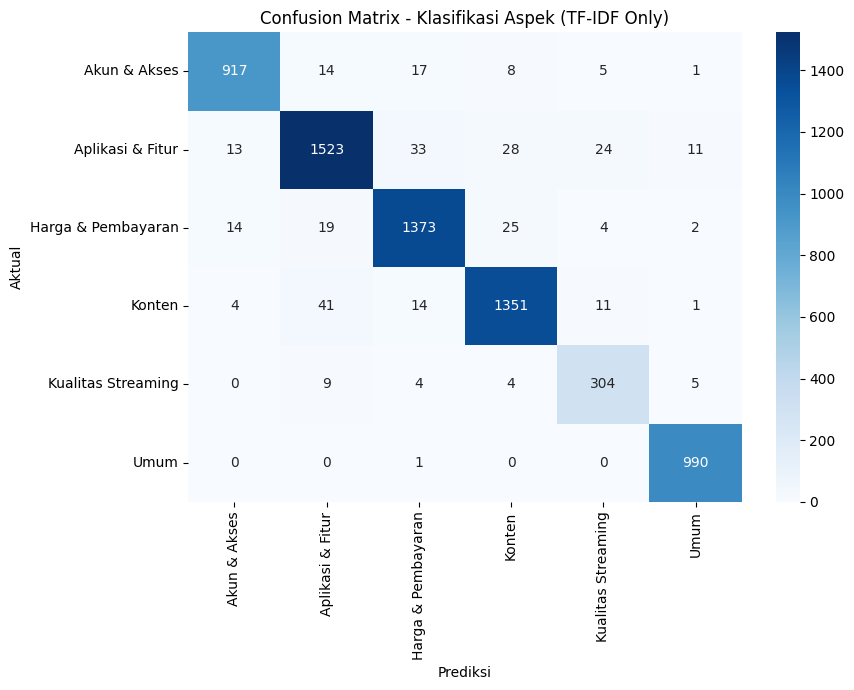


Analisis Overfitting
Accuracy Gap : 0.0404
Macro F1 Gap : 0.0446
Model cukup stabil dan tidak menunjukkan overfitting signifikan

Model klasifikasi aspek (tanpa lexicon) berhasil disimpan.


In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# =========================
# PATH
# =========================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
MODEL_DIR = "/content/drive/MyDrive/skripsi/model"
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_FILE = os.path.join(DATA_DIR, "dataset_aspek.csv")

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_FILE)
df = df.dropna(subset=["kalimat", "Aspek"])
df["kalimat"] = df["kalimat"].astype(str).str.lower()

X = df["kalimat"]
y = df["Aspek"]

print("Jumlah data:", len(df))
print("\nDistribusi label aspek:")
print(y.value_counts())

# =========================
# STRATIFIED 10-FOLD CROSS VALIDATION
# =========================
print("\nStratified 10-Fold Cross Validation")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    tfidf = TfidfVectorizer(
        ngram_range=(1,2),
        min_df=5,
        max_df=0.9,
        max_features=8000,
        sublinear_tf=True
    )

    X_train_vec = tfidf.fit_transform(X_train)
    X_test_vec  = tfidf.transform(X_test)

    model = LinearSVC(C=1.0, max_iter=8000, class_weight="balanced")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    fold_results.append([fold, acc, f1_macro])
    print(f"Fold {fold} - Accuracy: {acc:.4f}, Macro F1: {f1_macro:.4f}")

df_folds = pd.DataFrame(fold_results, columns=["Fold","Accuracy","Macro F1"])
print("\nRata-rata performa 10-Fold:")
print(df_folds.mean(numeric_only=True))

# Grafik performa per fold
plt.figure(figsize=(8,4))
plt.plot(df_folds["Fold"], df_folds["Accuracy"], marker='o', label="Accuracy")
plt.plot(df_folds["Fold"], df_folds["Macro F1"], marker='s', label="Macro F1")
plt.title("Performa Model Klasifikasi Aspek per Fold (Tanpa Lexicon)")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# TRAIN FINAL MODEL (80:20)
# =========================
print("\nPelatihan model final")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_weights = dict(zip(
    np.unique(y_train),
    compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
))

tfidf_final = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9,
    max_features=8000,
    sublinear_tf=True
)

X_train_vec = tfidf_final.fit_transform(X_train)
X_test_vec  = tfidf_final.transform(X_test)

svm_aspek = LinearSVC(C=1.0, max_iter=8000, class_weight=class_weights)
svm_aspek.fit(X_train_vec, y_train)

# =========================
# EVALUASI MODEL
# =========================
y_train_pred = svm_aspek.predict(X_train_vec)
y_test_pred  = svm_aspek.predict(X_test_vec)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
train_f1  = f1_score(y_train, y_train_pred, average="macro")
test_f1   = f1_score(y_test, y_test_pred, average="macro")

print("\nPerbandingan performa Train dan Test")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Train Macro F1 : {train_f1:.4f}")
print(f"Test Macro F1  : {test_f1:.4f}")

print("\nClassification Report (Test Data)\n")
print(classification_report(y_test, y_test_pred))

# =========================
# CONFUSION MATRIX
# =========================
labels_sorted = sorted(y.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels_sorted)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_sorted,
            yticklabels=labels_sorted)
plt.title("Confusion Matrix - Klasifikasi Aspek (TF-IDF Only)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

# =========================
# ANALISIS OVERFITTING
# =========================
acc_gap = train_acc - test_acc
f1_gap  = train_f1 - test_f1

print("\nAnalisis Overfitting")
print(f"Accuracy Gap : {acc_gap:.4f}")
print(f"Macro F1 Gap : {f1_gap:.4f}")

if acc_gap > 0.10 or f1_gap > 0.10:
    print("Model menunjukkan indikasi overfitting")
else:
    print("Model cukup stabil dan tidak menunjukkan overfitting signifikan")

# =========================
# SIMPAN MODEL
# =========================
joblib.dump(tfidf_final, os.path.join(MODEL_DIR, "tfidf_aspek.pkl"))
joblib.dump(svm_aspek, os.path.join(MODEL_DIR, "svm_aspek.pkl"))

print("\nModel klasifikasi aspek (tanpa lexicon) berhasil disimpan.")


VISUALISASI DATASET HASIL

Model aspek & sentimen berhasil dimuat
Jumlah komentar: 40926
Dataset hasil ABSA berhasil dibuat
Lokasi: /content/drive/MyDrive/skripsi/dataset/hasil_absa.csv


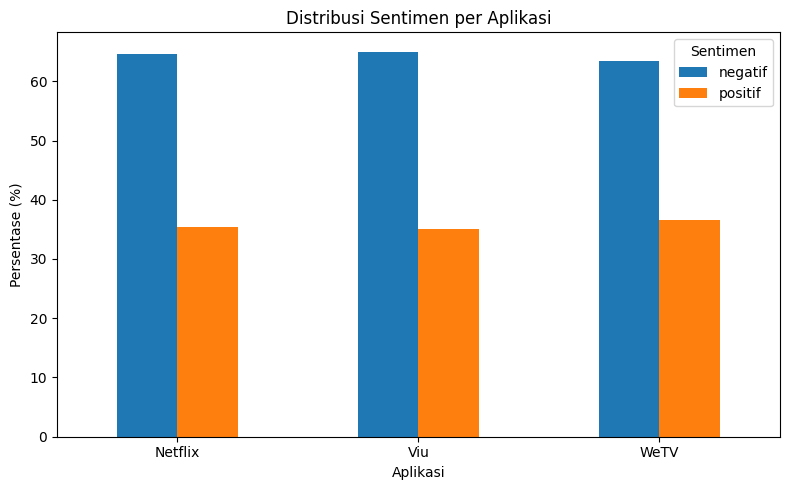

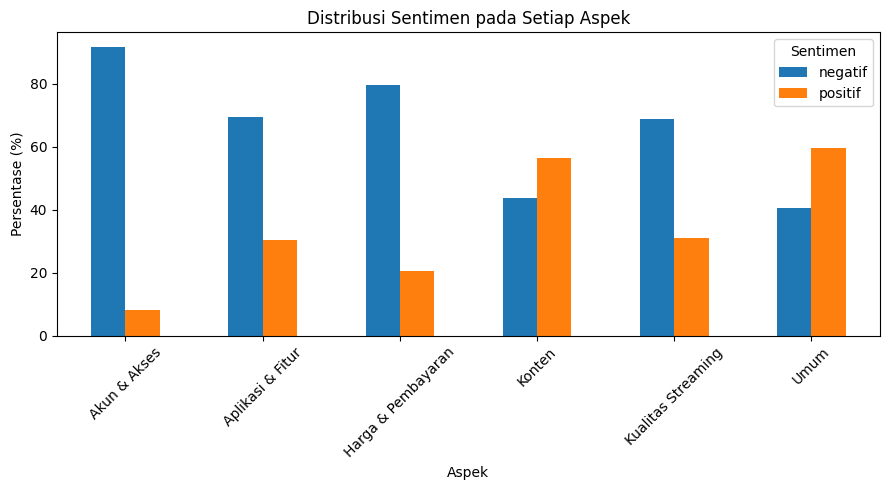


Aspek paling banyak dikeluhkan tiap aplikasi:
                            Aspek  Jumlah Keluhan
Nama Aplikasi                                    
Netflix              Akun & Akses            4229
Viu              Aplikasi & Fitur            4246
WeTV           Harga & Pembayaran            3064

Aspek paling banyak mendapat sentimen positif tiap aplikasi:
                Aspek  Jumlah Pujian
Nama Aplikasi                       
Netflix        Konten           2304
Viu            Konten           1910
WeTV           Konten           1440


In [ ]:
# =========================================================
# LOAD MODEL
# =========================================================
import pandas as pd
import re
import joblib
import matplotlib.pyplot as plt

tfidf_aspek   = joblib.load("/content/drive/MyDrive/skripsi/model/tfidf_aspek.pkl")
model_aspek   = joblib.load("/content/drive/MyDrive/skripsi/model/svm_aspek.pkl")

tfidf_sentimen = joblib.load("/content/drive/MyDrive/skripsi/model/tfidf_sentimen.pkl")
model_sentimen = joblib.load("/content/drive/MyDrive/skripsi/model/svm_sentimen.pkl")

print("Model aspek & sentimen berhasil dimuat")

# =========================================================
# LOAD DATA CLEAN (SUDAH ADA NEGATION HANDLING)
# =========================================================
DATA_FILE = "/content/drive/MyDrive/skripsi/dataset/datahasil_clean.csv"
df = pd.read_csv(DATA_FILE)

df = df.dropna(subset=["Komentar", "clean_text_stem"])
df["Komentar"] = df["Komentar"].astype(str)
df["clean_text_stem"] = df["clean_text_stem"].astype(str)

print("Jumlah komentar:", len(df))

# =========================================================
# FUNGSI SPLIT OPINI
# =========================================================
def split_opini(teks):
    bagian = re.split(r'\b(tapi|namun|tetapi|walaupun|meskipun|padahal|cuma)\b', teks)
    hasil = []
    for b in bagian:
        b = b.strip()
        if b and b not in ["tapi","namun","tetapi","walaupun","meskipun","padahal","cuma"]:
            hasil.append(b)
    return hasil

# =========================================================
# PROSES ABSA (TANPA NEGATION HANDLING LAGI)
# =========================================================
hasil = []

for _, row in df.iterrows():
    app = row.get("Nama Aplikasi", "Unknown")
    komentar_asli = row["Komentar"]
    teks_stem_full = row["clean_text_stem"]

    opini_list = split_opini(teks_stem_full)

    for opini_stem in opini_list:
        opini_stem = opini_stem.strip()
        if len(opini_stem.split()) < 2:
            continue

        # Prediksi aspek
        X_aspek = tfidf_aspek.transform([opini_stem])
        aspek = model_aspek.predict(X_aspek)[0]

        # Prediksi sentimen (LANGSUNG, TANPA HANDLE NEGATION)
        X_sent = tfidf_sentimen.transform([opini_stem])
        sentimen = model_sentimen.predict(X_sent)[0]

        hasil.append([app, komentar_asli, opini_stem, aspek, sentimen])

# =========================================================
# SIMPAN HASIL ABSA
# =========================================================
df_hasil = pd.DataFrame(hasil, columns=[
    "Nama Aplikasi",
    "Komentar Asli",
    "Opini (Stem)",
    "Aspek",
    "Sentimen"
])

OUT_FILE = "/content/drive/MyDrive/skripsi/dataset/hasil_absa.csv"
df_hasil.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")

print("Dataset hasil ABSA berhasil dibuat")
print("Lokasi:", OUT_FILE)


# =========================================================
# VISUALISASI 1 — SENTIMEN PER APLIKASI
# =========================================================
sentimen_app = pd.crosstab(
    df_hasil["Nama Aplikasi"],
    df_hasil["Sentimen"],
    normalize="index"
) * 100

sentimen_app.plot(kind="bar", figsize=(8,5))
plt.title("Distribusi Sentimen per Aplikasi")
plt.ylabel("Persentase (%)")
plt.xlabel("Aplikasi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# VISUALISASI 2 — SENTIMEN PER ASPEK
# =========================================================
sentimen_aspek = pd.crosstab(
    df_hasil["Aspek"],
    df_hasil["Sentimen"],
    normalize="index"
) * 100

sentimen_aspek.plot(kind="bar", figsize=(9,5))
plt.title("Distribusi Sentimen pada Setiap Aspek")
plt.ylabel("Persentase (%)")
plt.xlabel("Aspek")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================================================
# VISUALISASI 3 — ASPEK PALING DIKELUHKAN TIAP APLIKASI
# =========================================================
negatif_only = df_hasil[df_hasil["Sentimen"] == "negatif"]

keluhan = (
    negatif_only.groupby(["Nama Aplikasi","Aspek"])
    .size()
    .reset_index(name="Jumlah Keluhan")
    .sort_values(["Nama Aplikasi","Jumlah Keluhan"], ascending=[True,False])
)

print("\nAspek paling banyak dikeluhkan tiap aplikasi:")
print(keluhan.groupby("Nama Aplikasi").first())

# =========================================================
# VISUALISASI 4 — ASPEK PALING DISUKAI TIAP APLIKASI
# =========================================================
positif_only = df_hasil[df_hasil["Sentimen"] == "positif"]

pujian = (
    positif_only.groupby(["Nama Aplikasi","Aspek"])
    .size()
    .reset_index(name="Jumlah Pujian")
    .sort_values(["Nama Aplikasi","Jumlah Pujian"], ascending=[True,False])
)

print("\nAspek paling banyak mendapat sentimen positif tiap aplikasi:")
print(pujian.groupby("Nama Aplikasi").first())


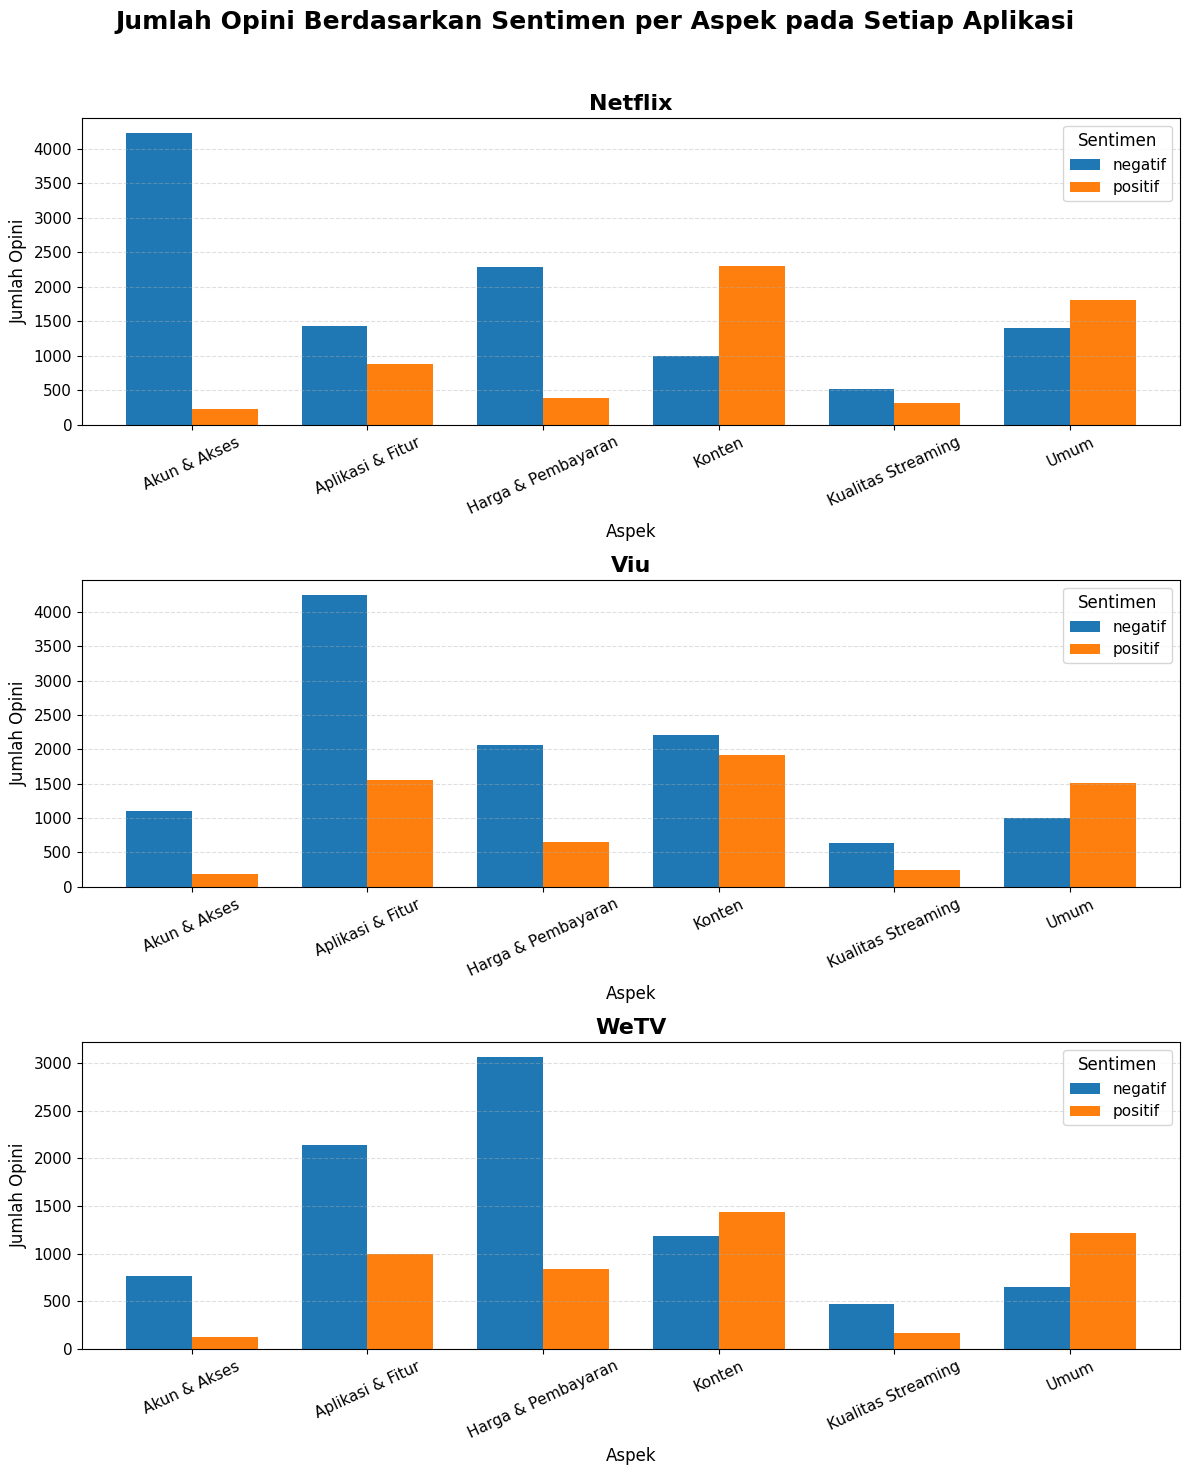

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# TANPA normalize → pakai jumlah asli
data = pd.crosstab(
    [df_hasil["Nama Aplikasi"], df_hasil["Aspek"]],
    df_hasil["Sentimen"]
)

apps = df_hasil["Nama Aplikasi"].unique()

fig, axes = plt.subplots(len(apps), 1, figsize=(12, 5*len(apps)), sharex=False)

if len(apps) == 1:
    axes = [axes]

for ax, app in zip(axes, apps):
    subset = data.loc[app]
    subset.plot(kind="bar", ax=ax, width=0.75)

    ax.set_title(f"{app}", fontsize=16, fontweight="bold")
    ax.set_xlabel("Aspek", fontsize=12)
    ax.set_ylabel("Jumlah Opini", fontsize=12)

    ax.tick_params(axis='x', rotation=25, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.legend(title="Sentimen", fontsize=11, title_fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle("Jumlah Opini Berdasarkan Sentimen per Aspek pada Setiap Aplikasi",
             fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fig.savefig("jumlah_opini_per_aspek_vertikal.png", dpi=300, bbox_inches="tight")


WORDCLOUD

In [ ]:
!pip install wordcloud


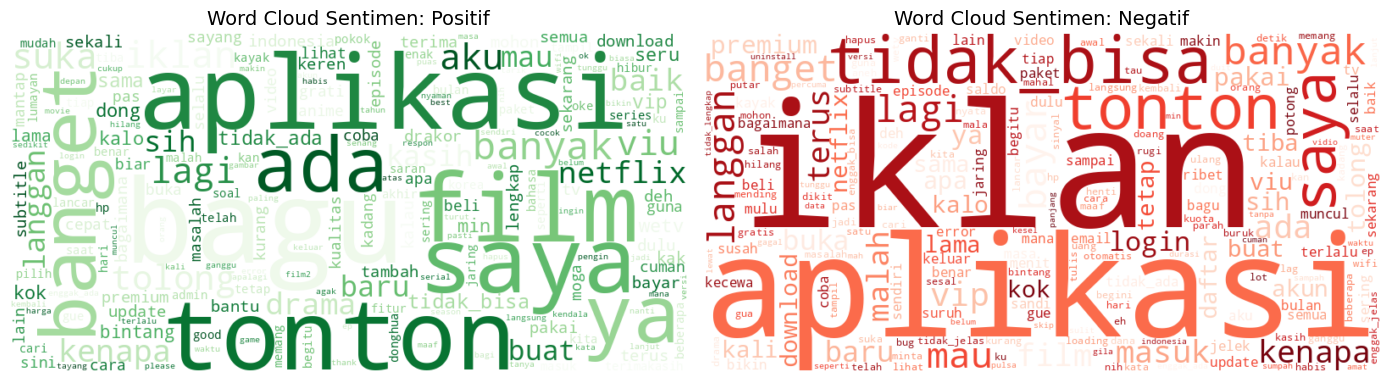

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Bersihkan data kosong
df_wc = df_hasil.dropna(subset=["Sentimen", "Opini (Stem)"]).copy()

sentimen_list = ["positif", "negatif"]
warna_map = {
    "positif": "Greens",
    "negatif": "Reds"
}

plt.figure(figsize=(14,6))

for i, sentimen in enumerate(sentimen_list, 1):
    df_sent = df_wc[df_wc["Sentimen"] == sentimen]
    text_sent = " ".join(df_sent["Opini (Stem)"].astype(str))

    if text_sent.strip() == "":
        print(f"Tidak ada data untuk sentimen {sentimen}")
        continue

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=warna_map[sentimen],
        collocations=False
    ).generate(text_sent)

    plt.subplot(1, 2, i)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud Sentimen: {sentimen.capitalize()}", fontsize=14)

plt.tight_layout()
plt.show()


Jumlah aspek ditemukan: 6
['Konten' 'Aplikasi & Fitur' 'Harga & Pembayaran' 'Akun & Akses' 'Umum'
 'Kualitas Streaming']


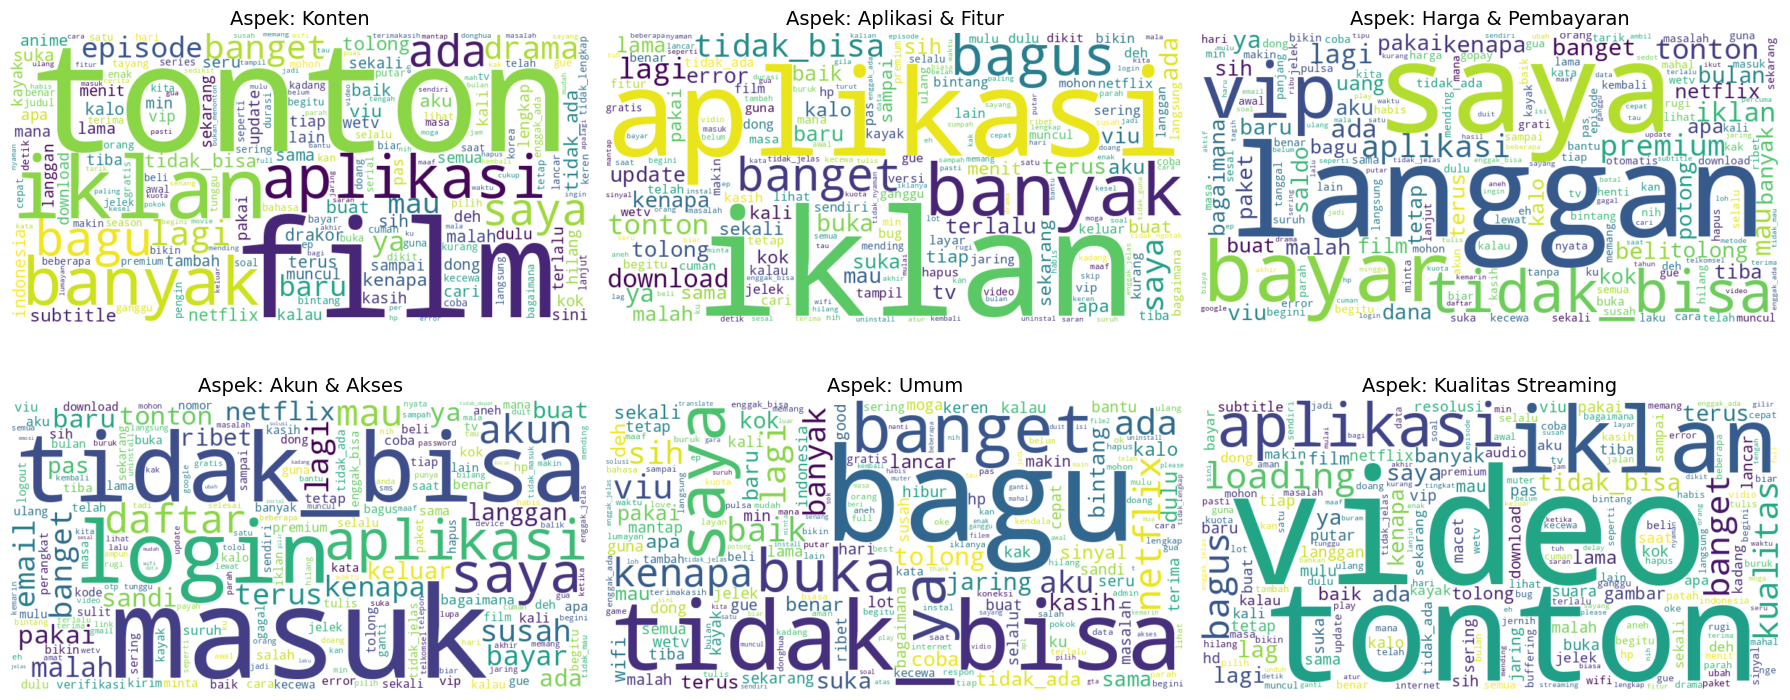

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math

# Pastikan tidak ada data kosong
df_wc = df_hasil.dropna(subset=["Aspek", "Opini (Stem)"]).copy()

aspek_list = df_wc["Aspek"].unique()
jumlah_aspek = len(aspek_list)

print("Jumlah aspek ditemukan:", jumlah_aspek)
print(aspek_list)

# Tentukan ukuran grid otomatis (misal 2 baris kalau 6 aspek)
cols = 3
rows = math.ceil(jumlah_aspek / cols)

plt.figure(figsize=(18, 8))

for i, aspek in enumerate(aspek_list, 1):
    df_aspek = df_wc[df_wc["Aspek"] == aspek]
    text_aspek = " ".join(df_aspek["Opini (Stem)"].astype(str))

    if text_aspek.strip() == "":
        continue

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        collocations=False
    ).generate(text_aspek)

    plt.subplot(rows, cols, i)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Aspek: {aspek}", fontsize=14)

plt.tight_layout()
plt.show()


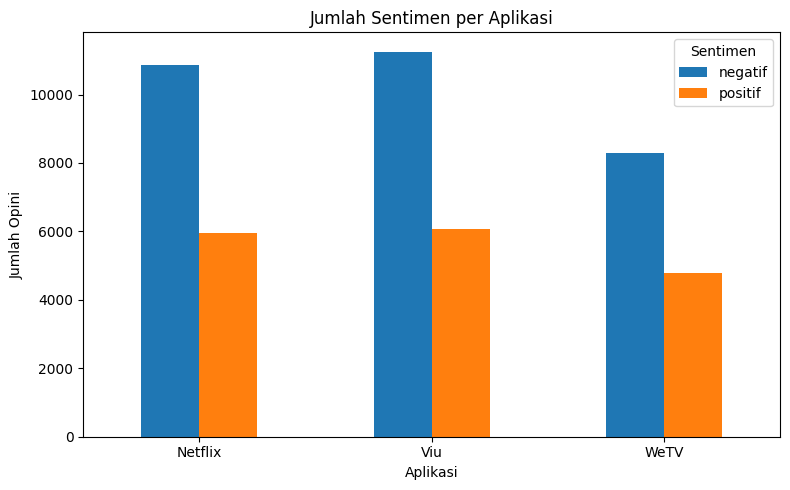

In [ ]:
# =========================================================
# VISUALISASI 1 — JUMLAH SENTIMEN PER APLIKASI (COUNT)
# =========================================================
sentimen_app = pd.crosstab(
    df_hasil["Nama Aplikasi"],
    df_hasil["Sentimen"]
)

sentimen_app.plot(kind="bar", figsize=(8,5))
plt.title("Jumlah Sentimen per Aplikasi")
plt.ylabel("Jumlah Opini")
plt.xlabel("Aplikasi")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


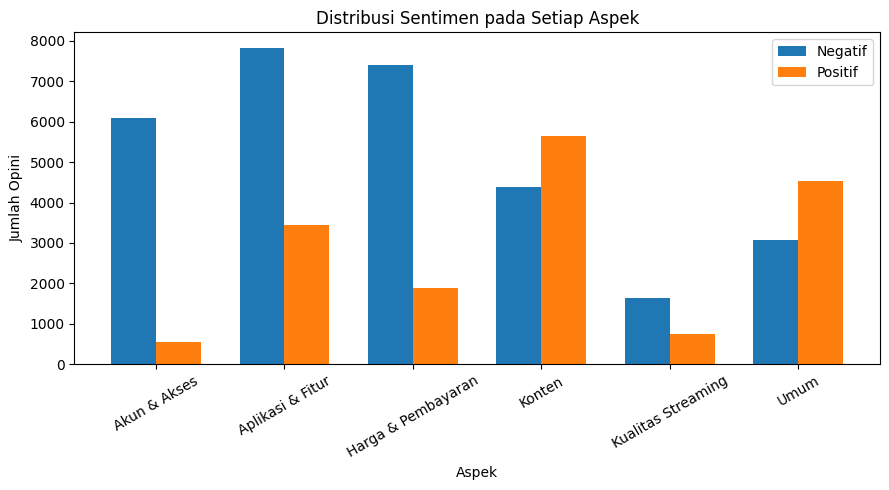

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Hitung jumlah sentimen per aspek
sentimen_aspek = pd.crosstab(
    df_hasil["Aspek"],
    df_hasil["Sentimen"]
)

# Pastikan urutan kolom konsisten
sentimen_aspek = sentimen_aspek[["negatif", "positif"]]

# Data untuk plot
aspek = sentimen_aspek.index.tolist()
negatif = sentimen_aspek["negatif"].values
positif = sentimen_aspek["positif"].values

x = np.arange(len(aspek))  # posisi aspek
width = 0.35  # lebar batang

plt.figure(figsize=(9,5))

plt.bar(x - width/2, negatif, width, label='Negatif')
plt.bar(x + width/2, positif, width, label='Positif')

plt.title("Distribusi Sentimen pada Setiap Aspek")
plt.xlabel("Aspek")
plt.ylabel("Jumlah Opini")
plt.xticks(x, aspek, rotation=30)
plt.legend()

plt.tight_layout()
plt.show()


FREKUENSI KATA

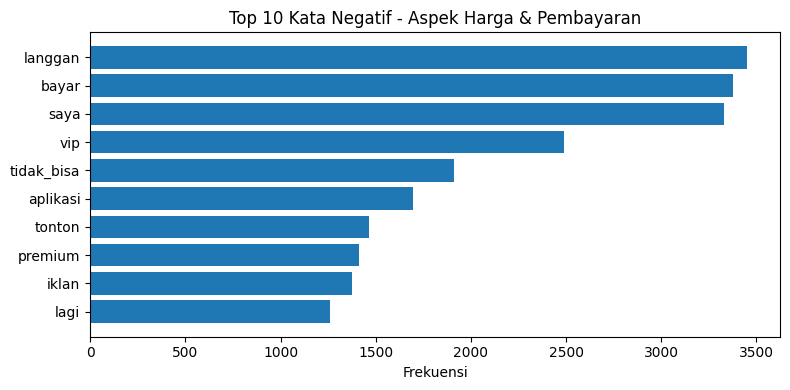

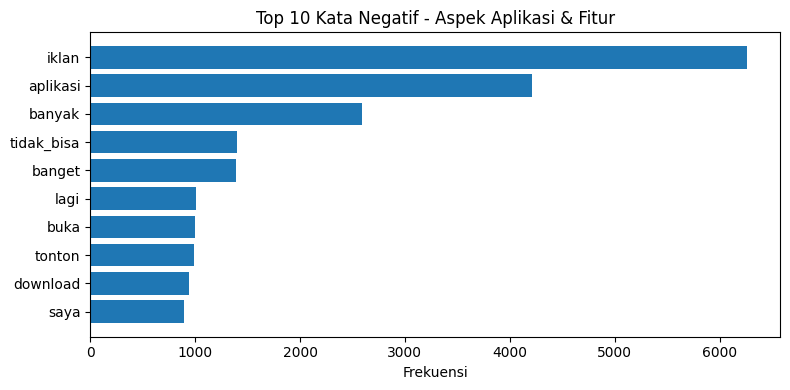

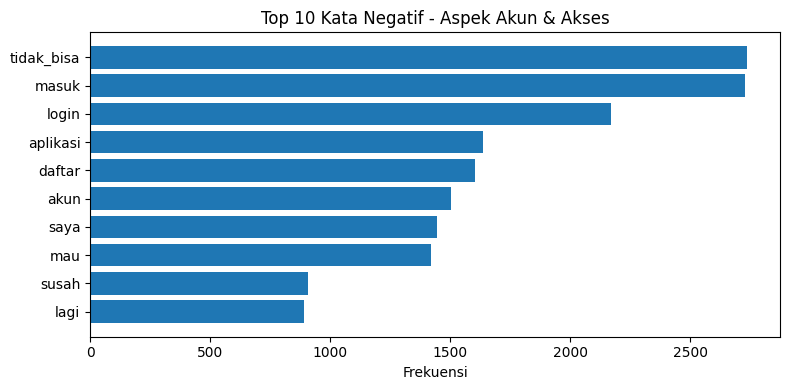

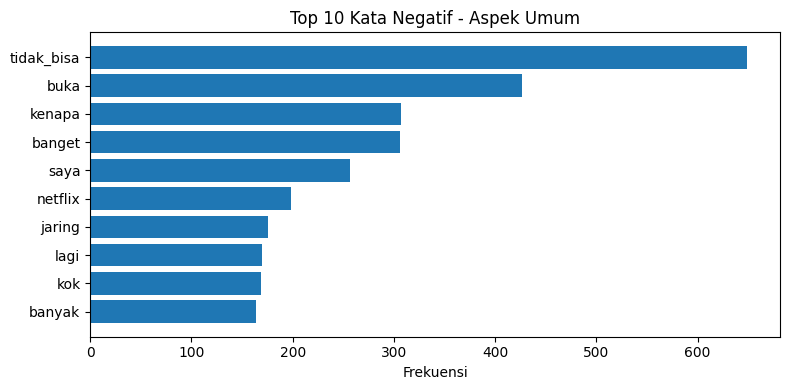

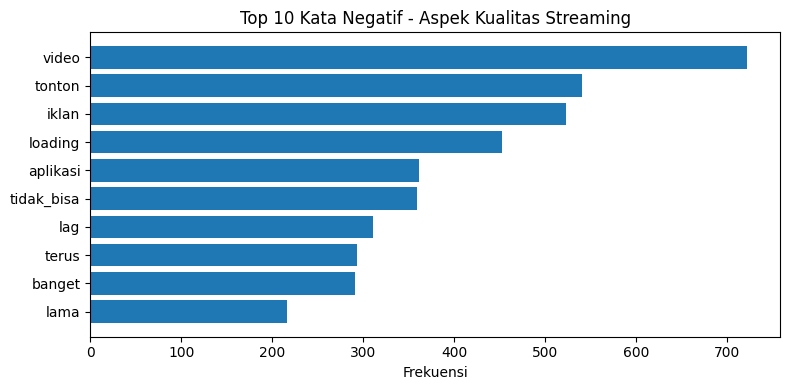

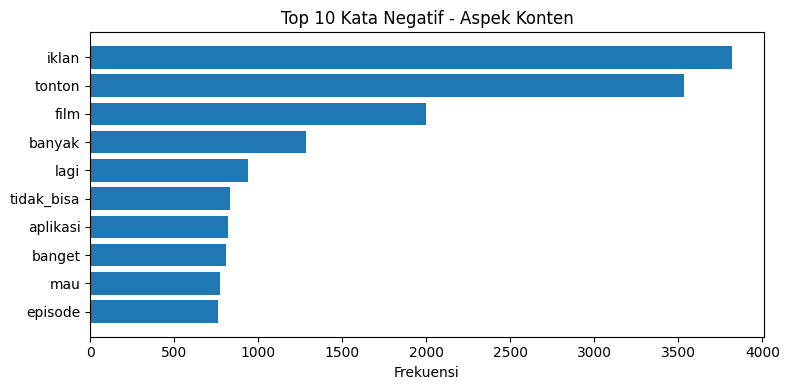

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Pastikan data bersih
df_wc = df_hasil.dropna(subset=["Sentimen", "Opini (Stem)", "Aspek"]).copy()

# Filter hanya negatif
df_neg = df_wc[df_wc["Sentimen"] == "negatif"]

top_n = 10  # jumlah kata teratas yang mau ditampilkan

for aspek in df_neg["Aspek"].unique():
    teks = " ".join(df_neg[df_neg["Aspek"] == aspek]["Opini (Stem)"])
    kata = teks.split()

    if len(kata) == 0:
        continue

    freq = Counter(kata).most_common(top_n)
    kata_list, jumlah = zip(*freq)

    plt.figure(figsize=(8,4))
    plt.barh(kata_list, jumlah)
    plt.title(f"Top {top_n} Kata Negatif - Aspek {aspek}")
    plt.xlabel("Frekuensi")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

df_wc = df_hasil.dropna(subset=["Aspek", "Sentimen", "Opini (Stem)"]).copy()

def get_top_words(df_subset, top_n=5):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(df_subset["Opini (Stem)"])
    word_counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    freq_df = pd.DataFrame({"Kata": words, "Frekuensi": word_counts})
    return freq_df.sort_values("Frekuensi", ascending=False).head(top_n)

hasil_ringkas = []

for aspek in sorted(df_wc["Aspek"].unique()):
    subset = df_wc[(df_wc["Aspek"] == aspek) & (df_wc["Sentimen"] == "negatif")]
    if len(subset) == 0:
        continue
    top_words = get_top_words(subset, top_n=5)
    top_words["Aspek"] = aspek
    hasil_ringkas.append(top_words)

df_top_negatif = pd.concat(hasil_ringkas)
df_top_negatif = df_top_negatif[["Aspek", "Kata", "Frekuensi"]]

print("📉 Top 5 Kata NEGATIF per Aspek")
display(df_top_negatif)


📉 Top 5 Kata NEGATIF per Aspek


,Aspek,Kata,Frekuensi
4005,Akun & Akses,tidak_bisa,2738
2505,Akun & Akses,masuk,2728
2398,Akun & Akses,login,2169
362,Akun & Akses,aplikasi,1637
1023,Akun & Akses,daftar,1602
2266,Aplikasi & Fitur,iklan,6263
465,Aplikasi & Fitur,aplikasi,4215
629,Aplikasi & Fitur,banyak,2589
5127,Aplikasi & Fitur,tidak_bisa,1404
600,Aplikasi & Fitur,banget,1391


IMPORT JSON

In [ ]:

# ================================
# IMPORT LIBRARY
# ================================
import pandas as pd
import numpy as np
import os
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================================
# PATH
# ================================
DATA_DIR = "/content/drive/MyDrive/skripsi/dataset"
MODEL_DIR = "/content/drive/MyDrive/skripsi/model"

# ================================
# LOAD MODEL
# ================================
print("Loading model...")
tfidf_sentimen = joblib.load(os.path.join(MODEL_DIR, "tfidf_sentimen.pkl"))
svm_sentimen   = joblib.load(os.path.join(MODEL_DIR, "svm_sentimen.pkl"))

tfidf_aspek = joblib.load(os.path.join(MODEL_DIR, "tfidf_aspek.pkl"))
svm_aspek   = joblib.load(os.path.join(MODEL_DIR, "svm_aspek.pkl"))
print("Model loaded!\n")

# ======================================================
# 🔵 EVALUASI SENTIMEN
# ======================================================
print("Evaluasi Model Sentimen...")

df_sent = pd.read_csv(os.path.join(DATA_DIR, "dataset_sentimen.csv"))
df_sent = df_sent.dropna(subset=["clean_text_stem", "Sentimen"])
df_sent["text_used"] = df_sent["clean_text_stem"].astype(str).str.strip()
df_sent = df_sent[df_sent["text_used"] != ""]

X_sent = df_sent["text_used"]
y_sent = df_sent["Sentimen"].str.lower()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

X_test_vec_s = tfidf_sentimen.transform(X_test_s)
y_pred_s = svm_sentimen.predict(X_test_vec_s)

sentimen_accuracy  = accuracy_score(y_test_s, y_pred_s)
sentimen_precision = precision_score(y_test_s, y_pred_s, average="macro")
sentimen_recall    = recall_score(y_test_s, y_pred_s, average="macro")
sentimen_f1        = f1_score(y_test_s, y_pred_s, average="macro")

print("Sentimen Accuracy :", sentimen_accuracy)
print("Sentimen Precision:", sentimen_precision)
print("Sentimen Recall   :", sentimen_recall)
print("Sentimen F1-Score :", sentimen_f1, "\n")

# ======================================================
# 🟣 EVALUASI ASPEK
# ======================================================
print("Evaluasi Model Aspek...")

df_aspek = pd.read_csv(os.path.join(DATA_DIR, "dataset_aspek.csv"))
df_aspek = df_aspek.dropna(subset=["kalimat", "Aspek"])
df_aspek["kalimat"] = df_aspek["kalimat"].astype(str).str.strip()

X_aspek = df_aspek["kalimat"]
y_aspek = df_aspek["Aspek"]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_aspek, y_aspek, test_size=0.2, random_state=42, stratify=y_aspek
)

X_test_vec_a = tfidf_aspek.transform(X_test_a)
y_pred_a = svm_aspek.predict(X_test_vec_a)

aspek_accuracy  = accuracy_score(y_test_a, y_pred_a)
aspek_precision = precision_score(y_test_a, y_pred_a, average="macro")
aspek_recall    = recall_score(y_test_a, y_pred_a, average="macro")
aspek_f1        = f1_score(y_test_a, y_pred_a, average="macro")

print("Aspek Accuracy :", aspek_accuracy)
print("Aspek Precision:", aspek_precision)
print("Aspek Recall   :", aspek_recall)
print("Aspek F1-Score :", aspek_f1, "\n")

# ======================================================
# 💾 SIMPAN METRICS KE JSON (UNTUK WEB)
# ======================================================
metrics_final = {
    "sentimen": {
        "accuracy": float(sentimen_accuracy),
        "precision": float(sentimen_precision),
        "recall": float(sentimen_recall),
        "f1_score": float(sentimen_f1)
    },
    "aspek": {
        "accuracy": float(aspek_accuracy),
        "precision": float(aspek_precision),
        "recall": float(aspek_recall),
        "f1_score": float(aspek_f1)
    }
}

with open(os.path.join(MODEL_DIR, "model_metrics.json"), "w") as f:
    json.dump(metrics_final, f, indent=4)

print("model_metrics.json berhasil dibuat!")


Loading model...
Model loaded!

Evaluasi Model Sentimen...
Sentimen Accuracy : 0.8594070482938654
Sentimen Precision: 0.8358741023048404
Sentimen Recall   : 0.8449161306547492
Sentimen F1-Score : 0.8400658546918898 

Evaluasi Model Aspek...
Aspek Accuracy : 0.9539143279172821
Aspek Precision: 0.9459375763147336
Aspek Recall   : 0.953912097728488
Aspek F1-Score : 0.949729715655871 

model_metrics.json berhasil dibuat!
